In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('train.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [36]:
df.isnull().sum()

passengerid      0
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
dtype: int64

In [18]:
df.drop(columns=['Ticket','Cabin','Name'],axis=1,inplace=True)

In [20]:
df.columns= df.columns.str.lower().str.strip()

In [29]:
df.isna().sum()

passengerid      0
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
dtype: int64

In [37]:
df['embarked'].fillna(df['embarked'].mode()[0],inplace=True)

C:\Users\ankit\AppData\Local\Temp\ipykernel_2828\1024298632.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna(df['embarked'].mode()[0],inplace=True)


In [38]:
df['embarked'].isna().sum()

np.int64(0)

In [40]:
df.age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

In [51]:
df['age'].fillna(df.age.mean(),inplace=True)

C:\Users\ankit\AppData\Local\Temp\ipykernel_2828\3310643935.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df.age.mean(),inplace=True)


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    object 
 4   age          891 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


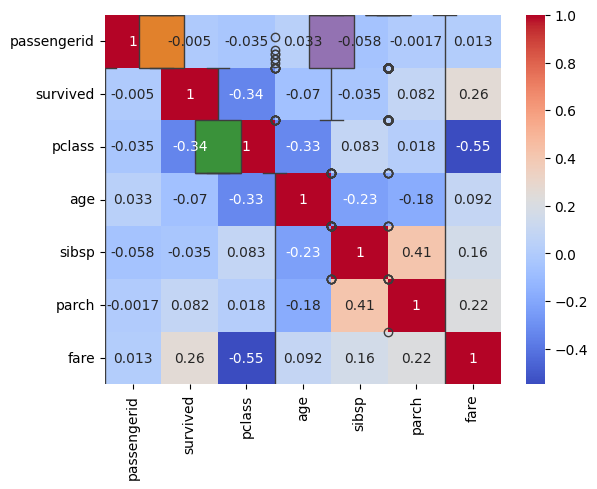

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)


corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


In [56]:
df.drop(['passengerid'],axis=1,inplace=True)

In [63]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [66]:
df['sex']=df['sex'].map({'male':1,'female':0})

In [59]:
df['pclass'].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [67]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S


In [78]:
ab=df

In [79]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ab = df.copy()

pclass_ohe = OneHotEncoder(
    drop='first',
    sparse_output=False
)

encoded = pclass_ohe.fit_transform(
    ab[['pclass', 'embarked']]
)

encoded_df = pd.DataFrame(
    encoded,
    columns=pclass_ohe.get_feature_names_out(['pclass', 'embarked']),
    index=ab.index
)

ab = pd.concat(
    [
        ab.drop(columns=['pclass', 'embarked']),
        encoded_df
    ],
    axis=1
)

In [80]:
ab

,survived,sex,age,sibsp,parch,fare,pclass_2,pclass_3,embarked_Q,embarked_S
0,0,1,22.000000,1,0,7.2500,0.0,1.0,0.0,1.0
1,1,0,38.000000,1,0,71.2833,0.0,0.0,0.0,0.0
2,1,0,26.000000,0,0,7.9250,0.0,1.0,0.0,1.0
3,1,0,35.000000,1,0,53.1000,0.0,0.0,0.0,1.0
4,0,1,35.000000,0,0,8.0500,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
886,0,1,27.000000,0,0,13.0000,1.0,0.0,0.0,1.0
887,1,0,19.000000,0,0,30.0000,0.0,0.0,0.0,1.0
888,0,0,29.699118,1,2,23.4500,0.0,1.0,0.0,1.0
889,1,1,26.000000,0,0,30.0000,0.0,0.0,0.0,0.0


In [81]:
df=ab.copy()

In [83]:
df.describe()

,survived,sex,age,sibsp,parch,fare,pclass_2,pclass_3,embarked_Q,embarked_S
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,0.647587,29.699118,0.523008,0.381594,32.204208,0.206510,0.551066,0.086420,0.725028
std,0.486592,0.477990,13.002015,1.102743,0.806057,49.693429,0.405028,0.497665,0.281141,0.446751
min,0.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,29.699118,0.000000,0.000000,14.454200,0.000000,1.000000,0.000000,1.000000
75%,1.000000,1.000000,35.000000,1.000000,0.000000,31.000000,0.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000,1.000000


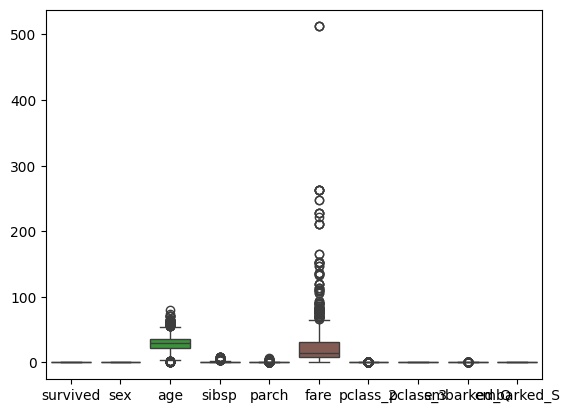

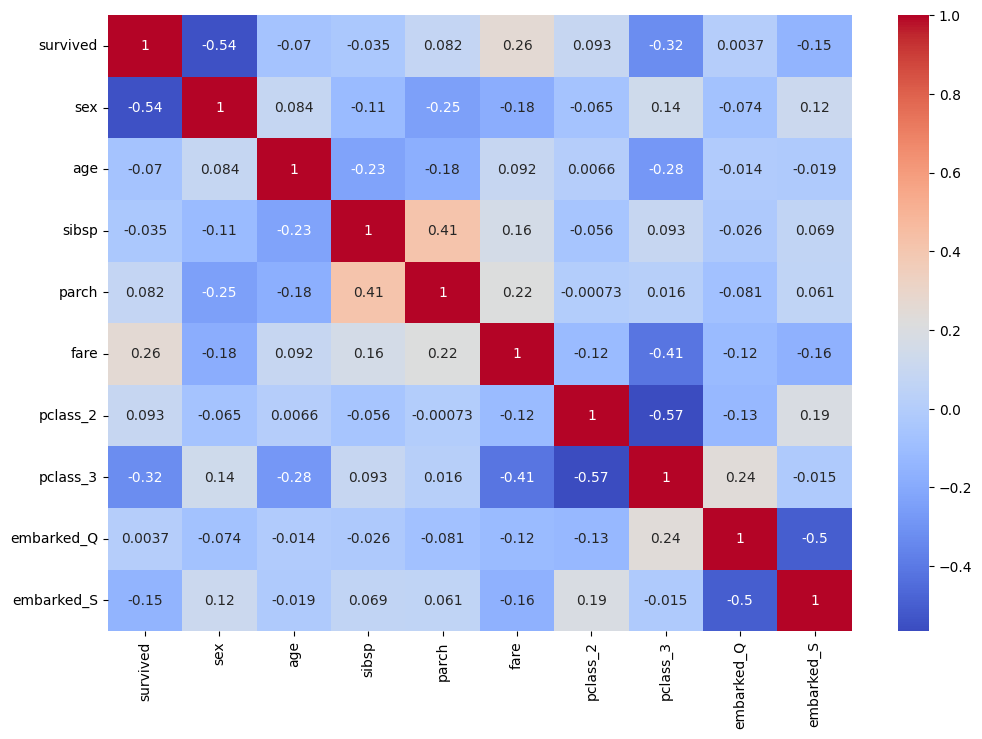

In [86]:
sns.boxplot(data=df.select_dtypes(include='number'))
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [99]:
X=df.drop('survived',axis=1)
y=df['survived']

In [93]:
from sklearn.preprocessing import StandardScaler

In [94]:
scaler=StandardScaler()

In [101]:
X=scaler.fit_transform(X)

In [102]:
from sklearn.model_selection import train_test_split

In [106]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [107]:
from sklearn.neighbors import KNeighborsClassifier

In [108]:
model=KNeighborsClassifier(5)

In [109]:
model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [111]:
y_pred=model.predict(X_test)

In [112]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.8044692737430168


In [116]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 82.68%


In [117]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 82.68%


In [115]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 77.09%


In [120]:

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

model.fit(X, y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [150]:
df_test=pd.read_csv('test.csv')

In [151]:
df_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [152]:
df_test.drop(columns=['PassengerId','Ticket','Cabin','Name'],axis=1,inplace=True)

In [153]:
df_test.columns= df_test.columns.str.lower().str.strip()

In [154]:
df_test['sex']=df_test['sex'].map({'male':1,'female':0})

In [155]:
df_test

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,1,34.5,0,0,7.8292,Q
1,3,0,47.0,1,0,7.0000,S
2,2,1,62.0,0,0,9.6875,Q
3,3,1,27.0,0,0,8.6625,S
4,3,0,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...
413,3,1,NaN,0,0,8.0500,S
414,1,0,39.0,0,0,108.9000,C
415,3,1,38.5,0,0,7.2500,S
416,3,1,NaN,0,0,8.0500,S


In [156]:
encoded_test = pclass_ohe.transform(
    df_test[['pclass', 'embarked']]
)

encoded_test = pd.DataFrame(
    encoded_test,
    columns=pclass_ohe.get_feature_names_out(['pclass', 'embarked']),
    index=df_test.index
)

df_test = pd.concat(
    [
        df_test.drop(columns=['pclass', 'embarked']),
        encoded_test
    ],
    axis=1
)

In [157]:
df_test

,sex,age,sibsp,parch,fare,pclass_2,pclass_3,embarked_Q,embarked_S
0,1,34.5,0,0,7.8292,0.0,1.0,1.0,0.0
1,0,47.0,1,0,7.0000,0.0,1.0,0.0,1.0
2,1,62.0,0,0,9.6875,1.0,0.0,1.0,0.0
3,1,27.0,0,0,8.6625,0.0,1.0,0.0,1.0
4,0,22.0,1,1,12.2875,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
413,1,NaN,0,0,8.0500,0.0,1.0,0.0,1.0
414,0,39.0,0,0,108.9000,0.0,0.0,0.0,0.0
415,1,38.5,0,0,7.2500,0.0,1.0,0.0,1.0
416,1,NaN,0,0,8.0500,0.0,1.0,0.0,1.0


In [161]:
X_test=scaler.transform(df_test)

In [162]:
X_test

array([[ 0.73769513,  0.36944878, -0.4745452 , ...,  0.90258736,
         3.25137334, -1.62380254],
       [-1.35557354,  1.33137817,  0.43279337, ...,  0.90258736,
        -0.30756234,  0.61583843],
       [ 0.73769513,  2.48569343, -0.4745452 , ..., -1.10792599,
         3.25137334, -1.62380254],
       ...,
       [ 0.73769513,  0.67726619, -0.4745452 , ...,  0.90258736,
        -0.30756234,  0.61583843],
       [ 0.73769513,         nan, -0.4745452 , ...,  0.90258736,
        -0.30756234,  0.61583843],
       [ 0.73769513,         nan,  0.43279337, ...,  0.90258736,
        -0.30756234, -1.62380254]], shape=(418, 9))

In [167]:
final_pred=model.predict(X_test)

In [174]:
df_sub=pd.read_csv('test.csv')

In [176]:
df_sub.drop(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch','Ticket', 'Fare', 'Cabin', 'Embarked'],axis=1,inplace=True)

In [177]:
df_sub

,PassengerId
0,892
1,893
2,894
3,895
4,896
...,...
413,1305
414,1306
415,1307
416,1308


In [178]:
df_sub['Survived'] = final_pred

In [184]:
df_sub

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [185]:
df_sub.to_csv('submission.csv', index=False)